In [593]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln_control import Model_ALN_control
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [758]:
a = Model_ALN_control()

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 100
tol = 1e-12
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

init_state_vars = np.array( [a.params.rates_exc_init, a.params.rates_inh_init,
                             a.params.mufe_init, a.params.mufi_init, a.params.IA_init,
                             a.params.seem_init, a.params.seim_init, a.params.siem_init, a.params.siim_init,
                             a.params.seev_init, a.params.seiv_init, a.params.siev_init, a.params.siiv_init,
                             a.params.mue_ou[0], a.params.mui_ou[0]] )

init_vars = a.init_vars


def setinitvars(iv):
    #print(a.params["rates_exc_init"])
    for i in range(len(init_vars)):
        a.params[init_vars[i]] = iv[i]
    #print(iv[0])
    #print(a.params["rates_exc_init"])

[[[5.00000000e-03 1.18648366e+01 1.19205664e+01 1.20717853e+01
   1.22302812e+01]
  [5.00000000e-03 2.03507045e+01 2.05549786e+01 2.07535601e+01
   2.09609591e+01]]]
rates_exc  :  [[5.00000000e-03 1.18648366e+01 1.19205664e+01 1.20717853e+01
  1.22302812e+01]]
rates_inh  :  [[5.00000000e-03 2.03507045e+01 2.05549786e+01 2.07535601e+01
  2.09609591e+01]]
mufe  :  [[1.5        1.50513107 1.51764193 1.53052558 1.5436204 ]]
mufi  :  [[1.5        1.50938999 1.51851516 1.52793895 1.53758243]]
IA  :  [[100.         100.18385613 100.36842583 100.55336358 100.73879913]]
seem  :  [[0.25       0.23753704 0.31500832 0.37990471 0.43484189]]
seim  :  [[0.25       0.24501136 0.28667038 0.32536872 0.36128862]]
siem  :  [[0.25       0.23753462 0.30916429 0.36972287 0.42146968]]
siim  :  [[0.25       0.24502287 0.33380727 0.41062854 0.47699863]]
seev  :  [[0.005      0.00450297 0.01147292 0.01461093 0.01554075]]
seiv  :  [[0.005      0.00480115 0.00938782 0.0127336  0.01508076]]
siev  :  [[0.005      0.

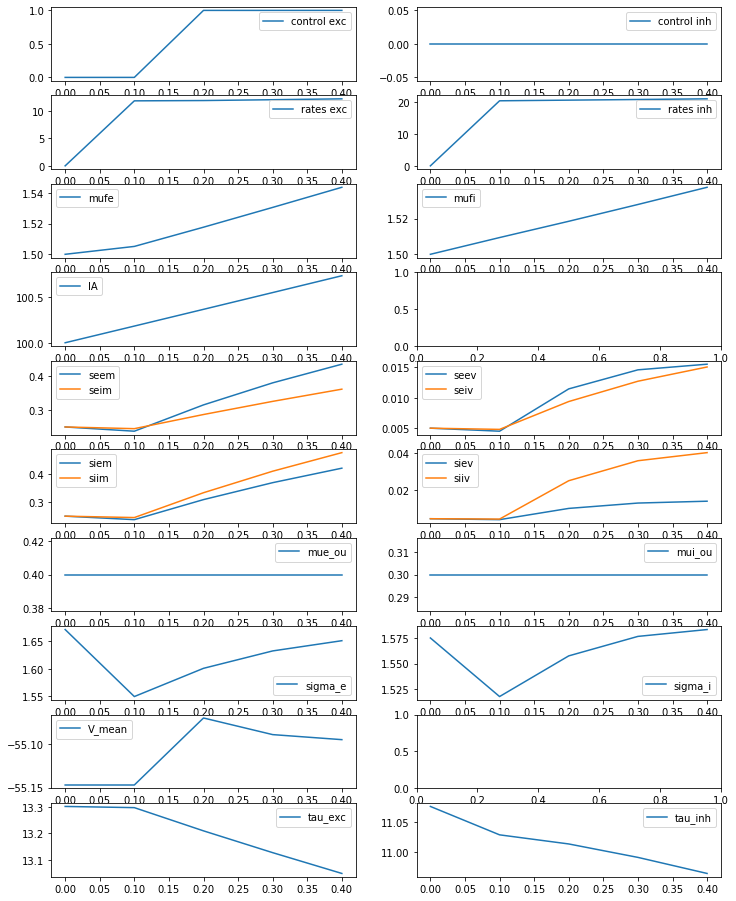

In [772]:
dur = 0.3
dur_pre = .1
dur_post = 0.

a.params.duration = dur + dur_pre
a.params.ext_exc_current = 2.
a.params.ext_inh_current = 2.

target0 = a.getZeroTarget()
control1 = a.getZeroControl()

#control1[0,0,:] += 1.
control1[0,0,int(dur_pre/a.params.dt + 1):] += 1.
#control1[0,0,int(dur_pre/a.params.dt):] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

#control1[0,1,2] += 1.
#control1[0,1,int(dur_pre/a.params.dt):] += np.cos(6.*np.arange(0,dur+a.params.dt,a.params.dt))

setinitvars(init_state_vars)
a.run(control=control1)

target0[:,0,:] = a.state["rates_exc"][0,:]
target0[:,1,:] = a.state["rates_inh"][0,:]
print(target0)


fig, axes = plt.subplots(10,2, figsize=(12, 16))
axes[0,0].plot(a.t, control1[0,0,:], label="control exc")
axes[0,1].plot(a.t, control1[0,1,:], label="control inh")
axes[1,0].plot(a.t, a.state["rates_exc"][0,:], label="rates exc")
axes[1,1].plot(a.t, a.state["rates_inh"][0,:], label="rates inh")
axes[2,0].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[2,1].plot(a.t, a.state["mufi"][0,:], label="mufi")
axes[3,0].plot(a.t, a.state["IA"][0,:], label="IA")

axes[4,0].plot(a.t, a.state["seem"][0,:], label="seem")
axes[4,0].plot(a.t, a.state["seim"][0,:], label="seim")
axes[5,0].plot(a.t, a.state["siem"][0,:], label="siem")
axes[5,0].plot(a.t, a.state["siim"][0,:], label="siim")

axes[4,1].plot(a.t, a.state["seev"][0,:], label="seev")
axes[4,1].plot(a.t, a.state["seiv"][0,:], label="seiv")
axes[5,1].plot(a.t, a.state["siev"][0,:], label="siev")
axes[5,1].plot(a.t, a.state["siiv"][0,:], label="siiv")

axes[6,0].plot(a.t, a.state["mue_ou"][0,:], label="mue_ou")
axes[6,1].plot(a.t, a.state["mui_ou"][0,:], label="mui_ou")

axes[7,0].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[7,1].plot(a.t, a.state["sigmai_f"][0,:], label="sigma_i")
axes[8,0].plot(a.t, a.state["Vmean_exc"][0,:], label="V_mean")
axes[9,0].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
axes[9,1].plot(a.t, a.state["tau_inh"][0,:], label="tau_inh")

for i in range(10):
    for j in range(2):
        if ((i,j) != (3,1) and (i,j) != (8,1)):
            axes[i,j].legend()


states = a.state_vars

states0 = np.zeros(( len(states), int(round((dur+dur_pre)/a.params.dt,1) + 1) ))
for o in range(len(states)):
    print(states[o], " : ", a.state[states[o]])
    states0[o] = a.state[states[o]]
    
    
del_init_vars = np.zeros( ( init_state_vars.shape ))
for o in range(len(init_vars)):
    del_init_vars[o] = a.state[states[o]][:,int(dur_pre/a.params.dt)]
    
#print(del_init_vars)

In [773]:
a.params.duration = dur

target = a.getZeroTarget()
target = target0[:,:,int(dur_pre/a.params.dt):]
print(target)

control2 = a.getZeroControl()
#control2 += 1.

cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

[[[11.8648366  11.92056645 12.07178532 12.23028118]
  [20.35070451 20.55497862 20.75356012 20.96095905]]]
set cost params


In [776]:
max_cntrl = 10. * 5.
start_step = 100.
max_it = 10

setinitvars(del_init_vars)
#setinitvars(init_state_vars)

dur_pre = 0.0

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

err = False
for c in range(len(A1_costA)-1):
    if A1_costA[c] < A1_costA[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")
    
states1 = np.zeros(( states0.shape ))
for o in range(len(states)):
    #print(A1_bestStateA[0,o,:])
    states1[o,1:] = A1_bestStateA[0,o,:]
    states1[o,:1] = states0[o,:1]

mufe sim = [1.50513107 1.51012133 1.51547108 1.52102137]
target =  [[[11.8648366  11.92056645 12.07178532 12.23028118]
  [20.35070451 20.55497862 20.75356012 20.96095905]]]
control =  [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]]]
RUN  0 , total integrated cost =  0.0024770402754472256
RUN  1 , total integrated cost =  1.4009336814530921e-05
Using initial step.
RUN  2 , total integrated cost =  5.327015455720094e-06
Using initial step.
RUN  3 , total integrated cost =  2.126907986783923e-06
RUN  4 , total integrated cost =  1.8306355532357799e-06
RUN  5 , total integrated cost =  1.5768890337308798e-06
RUN  6 , total integrated cost =  1.3584451359383248e-06
RUN  7 , total integrated cost =  1.1702098611950276e-06
RUN  8 , total integrated cost =  1.0084281651370503e-06
RUN  9 , total integrated cost =  8.692415859747277e-07
RUN  10 , total integrated cost =  7.491361411768322e-07
Improved over  10  iterations by  99.96975680417462  percent.
max abs value of final gradient =  0.00024146126710305064

In [777]:
setinitvars(init_state_vars)

dur_pre = .1

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

err = False
for c in range(len(A1_costA)-1):
    if A1_costA[c] < A1_costA[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")
    
states2 = np.zeros(( states0.shape ))
for o in range(len(states)):
    #print(A1_bestStateA[0,o,:])
    states2[o,:] = A1_bestStateA[0,o,:]

mufe pre = [1.5        1.50513107]
mufe sim = [1.50513107 1.51012133 1.51547108 1.52102137]
target =  [[[11.8648366  11.92056645 12.07178532 12.23028118]
  [20.35070451 20.55497862 20.75356012 20.96095905]]]
control =  [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]]]
RUN  0 , total integrated cost =  0.0024770402754472256
RUN  1 , total integrated cost =  1.4009336814530921e-05
Using initial step.
RUN  2 , total integrated cost =  5.327015455720094e-06
Using initial step.
RUN  3 , total integrated cost =  2.126907986783923e-06
RUN  4 , total integrated cost =  1.8306355532357799e-06
RUN  5 , total integrated cost =  1.5768890337308798e-06
RUN  6 , total integrated cost =  1.3584451359383248e-06
RUN  7 , total integrated cost =  1.1702098611950276e-06
RUN  8 , total integrated cost =  1.0084281651370503e-06
RUN  9 , total integrated cost =  8.692415859747277e-07
RUN  10 , total integrated cost =  7.491361411768322e-07
Improved over  10  iterations by  99.96975680417462  percent.
max abs value of final

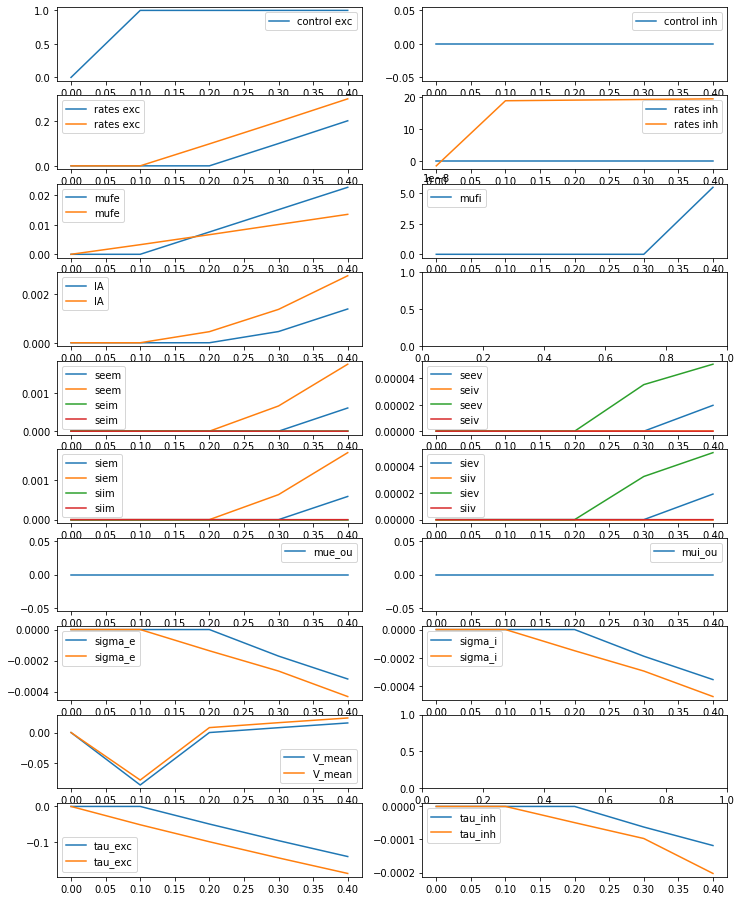

In [769]:
a.params.duration = dur + dur_pre
a.run(control=a.getZeroControl())

fig, axes = plt.subplots(10,2, figsize=(12, 16))
axes[0,0].plot(a.t, control1[0,0,:], label="control exc")
axes[0,1].plot(a.t, control1[0,1,:], label="control inh")
axes[1,0].plot(a.t, states0[0,:]-states1[0,:], label="rates exc")
axes[1,0].plot(a.t, states0[0,:]-states2[0,:], label="rates exc")
#axes[1,0].plot(a.t, states1[0,:], label="rates exc")
axes[1,1].plot(a.t, states0[1,:]-states1[1,:], label="rates inh")
axes[1,1].plot(a.t, states0[1,:]-states1[2,:], label="rates inh")
#axes[1,1].plot(a.t, states1[1,:], label="rates inh")
axes[2,0].plot(a.t, states0[2,:]-states1[2,:], label="mufe")
axes[2,0].plot(a.t, states0[2,:]-states1[3,:], label="mufe")
#axes[2,0].plot(a.t, states1[2,:], label="mufe")
axes[2,1].plot(a.t, states0[3,:]-states1[3,:], label="mufi")
#axes[2,1].plot(a.t, states1[3,:], label="mufi")
axes[3,0].plot(a.t, states0[4,:]-states1[4,:], label="IA")
axes[3,0].plot(a.t, states0[4,:]-states2[4,:], label="IA")
#axes[3,0].plot(a.t, states1[4,:], label="IA")

axes[4,0].plot(a.t, states0[5,:]-states1[5,:], label="seem")
axes[4,0].plot(a.t, states0[5,:]-states2[5,:], label="seem")
#axes[4,0].plot(a.t, states1[5,:], label="seem")
axes[4,0].plot(a.t, states0[6,:]-states1[6,:], label="seim")
axes[4,0].plot(a.t, states0[6,:]-states2[6,:], label="seim")
#axes[4,0].plot(a.t, states1[6,:], label="seim")
axes[5,0].plot(a.t, states0[7,:]-states1[7,:], label="siem")
axes[5,0].plot(a.t, states0[7,:]-states2[7,:], label="siem")
#axes[5,0].plot(a.t, states1[7,:], label="siem")
axes[5,0].plot(a.t, states0[8,:]-states1[8,:], label="siim")
axes[5,0].plot(a.t, states0[8,:]-states2[8,:], label="siim")
#axes[5,0].plot(a.t, states1[8,:], label="siim")

axes[4,1].plot(a.t, states0[9,:]-states1[9,:], label="seev")
axes[4,1].plot(a.t, states0[10,:]-states1[10,:], label="seiv")
axes[5,1].plot(a.t, states0[11,:]-states1[11,:], label="siev")
axes[5,1].plot(a.t, states0[12,:]-states1[12,:], label="siiv")
axes[4,1].plot(a.t, states0[9,:]-states2[9,:], label="seev")
axes[4,1].plot(a.t, states0[10,:]-states2[10,:], label="seiv")
axes[5,1].plot(a.t, states0[11,:]-states2[11,:], label="siev")
axes[5,1].plot(a.t, states0[12,:]-states2[12,:], label="siiv")

axes[6,0].plot(a.t, states0[13,:]-states1[13,:], label="mue_ou")
axes[6,1].plot(a.t, states0[14,:]-states1[14,:], label="mui_ou")

axes[7,0].plot(a.t, states0[15,:]-states1[15,:], label="sigma_e")
axes[7,1].plot(a.t, states0[16,:]-states1[16,:], label="sigma_i")
axes[8,0].plot(a.t, states0[17,:]-states1[17,:], label="V_mean")
axes[9,0].plot(a.t, states0[18,:]-states1[18,:], label="tau_exc")
axes[9,1].plot(a.t, states0[19,:]-states1[19,:], label="tau_inh")
axes[7,0].plot(a.t, states0[15,:]-states2[15,:], label="sigma_e")
axes[7,1].plot(a.t, states0[16,:]-states2[16,:], label="sigma_i")
axes[8,0].plot(a.t, states0[17,:]-states2[17,:], label="V_mean")
axes[9,0].plot(a.t, states0[18,:]-states2[18,:], label="tau_exc")
axes[9,1].plot(a.t, states0[19,:]-states2[19,:], label="tau_inh")

for i in range(10):
    for j in range(2):
        if ((i,j) != (3,1) and (i,j) != (8,1)):
            axes[i,j].legend()

ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

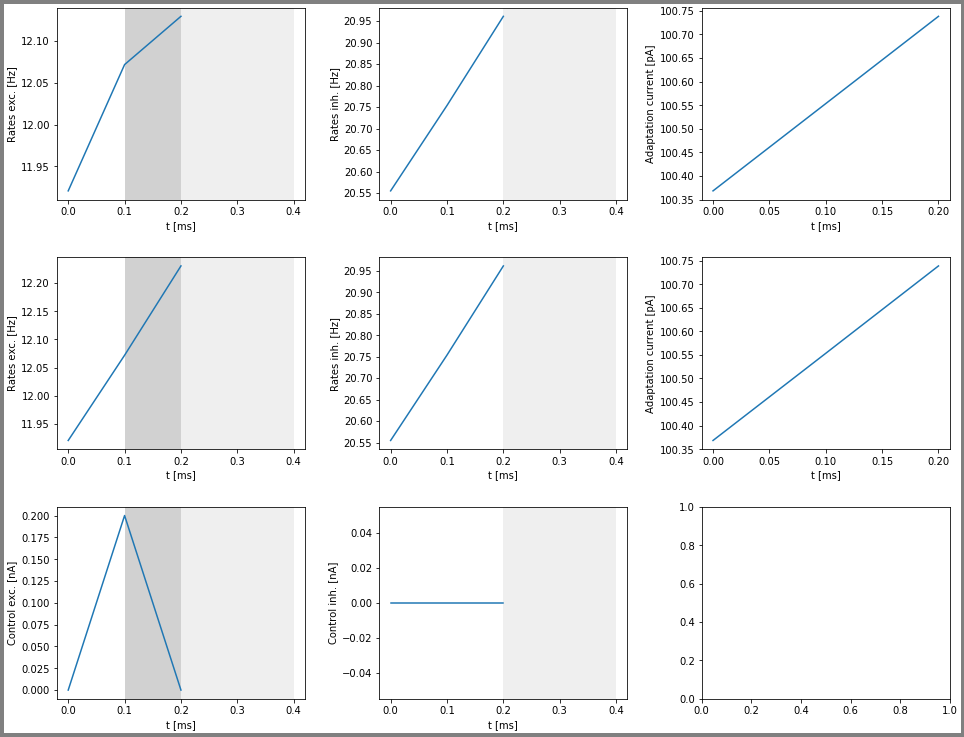

In [658]:
"""
state =  [[[ 1.19205664e+01  1.20717853e+01  1.21295693e+01]
  [ 2.05549786e+01  2.07535601e+01  2.09609591e+01]
  [ 1.51764193e+00  1.52295505e+00  1.52846910e+00]
  [ 1.51851516e+00  1.52793895e+00  1.53758243e+00]
  [ 1.00368426e+02  1.00553364e+02  1.00738337e+02]
  [ 3.15008318e-01  3.79904706e-01  4.34841888e-01]
  [ 2.86670381e-01  3.25368716e-01  3.61288617e-01]
  [ 3.09164290e-01  3.69722872e-01  4.21469684e-01]
  [ 3.33807266e-01  4.10628544e-01  4.76998631e-01]
  [ 1.14729167e-02  1.46109281e-02  1.55407453e-02]
  [ 9.38781875e-03  1.27336042e-02  1.50807560e-02]
  [ 1.04695731e-02  1.33109192e-02  1.42920930e-02]
  [ 2.51660612e-02  3.57716312e-02  4.00688460e-02]
  [ 4.00000000e-01  4.00000000e-01  4.00000000e-01]
  [ 3.00000000e-01  3.00000000e-01  3.00000000e-01]
  [ 1.60083867e+00  1.63235752e+00  1.65107885e+00]
  [ 1.55750311e+00  1.57642114e+00  1.58328120e+00]
  [-5.50886900e+01 -5.50886900e+01 -5.51024535e+01]
  [ 1.32091143e+01  1.31753820e+01  1.31431643e+01]
  [ 1.10132761e+01  1.09909474e+01  1.09643272e+01]]]
target =  [[[11.92056645 12.07178532 12.23028118]
  [20.55497862 20.75356012 20.96095905]]]

RUN  0 , total integrated cost =  0.0005071439157981297
"""
#dur_pre = 0.2
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, del_init_vars, target,
                      path, filename_ = 'simp')
#dur_pre = 0.

In [493]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 1

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

True
RUN  0 , total integrated cost:  1.2821218246604862
change helped, counter =  2
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  3
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  4
change helped, counter =  1
change helped, counter =  2
change helped, counter =  2
change helped, counter =  2
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
change helped, counter =  2
change helped, counter =  2
change helped, coun

ValueError: could not broadcast input array from shape (101) into shape (1)

[[[0.         0.13753422 0.13026481 0.10586687 0.0612895  0.        ]
  [0.         0.10669054 0.09359861 0.0541608  0.01949457 0.        ]]]


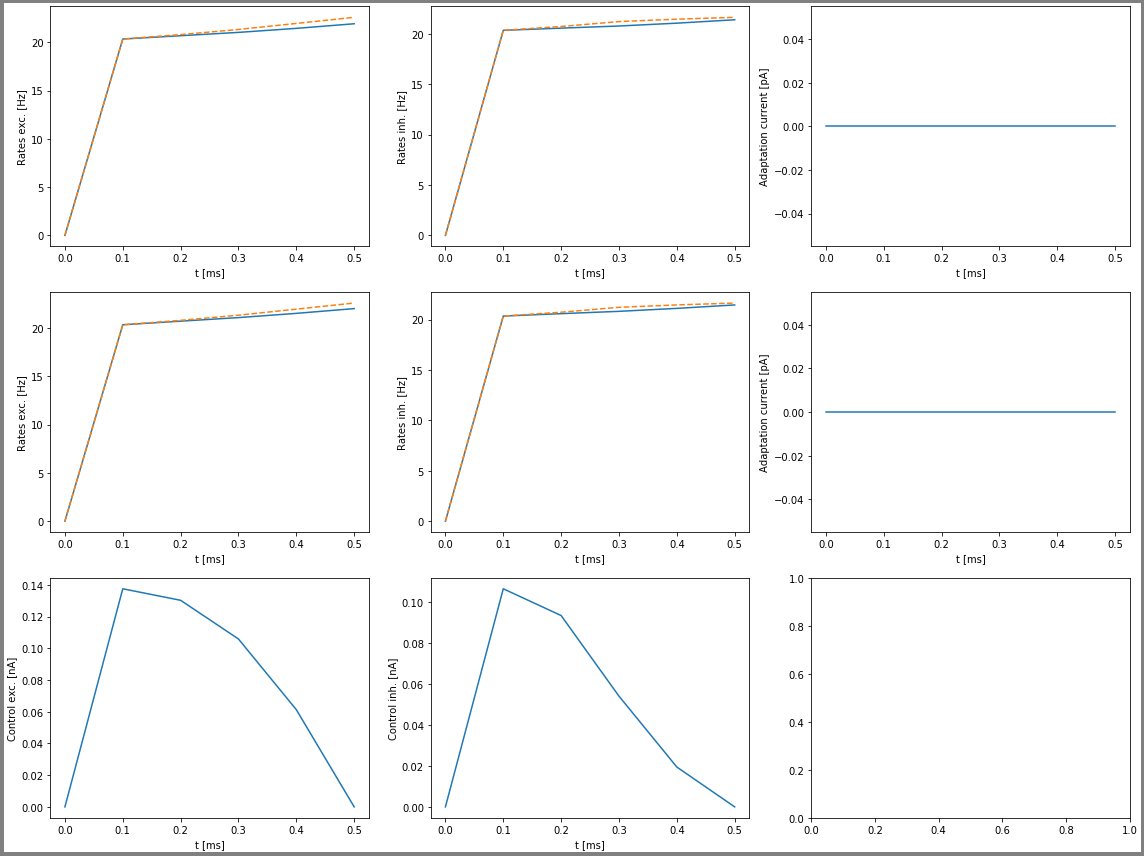

In [166]:
# 0.05372426098063908
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

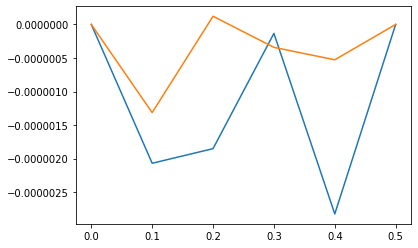

In [279]:
diff0 = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]
diff1 = A2_bestControlA[0,1,:] - A1_bestControlA[0,1,:]

plt.plot(a.t, diff0)
plt.plot(a.t, diff1)
plt.show()

(350, 64, 2)


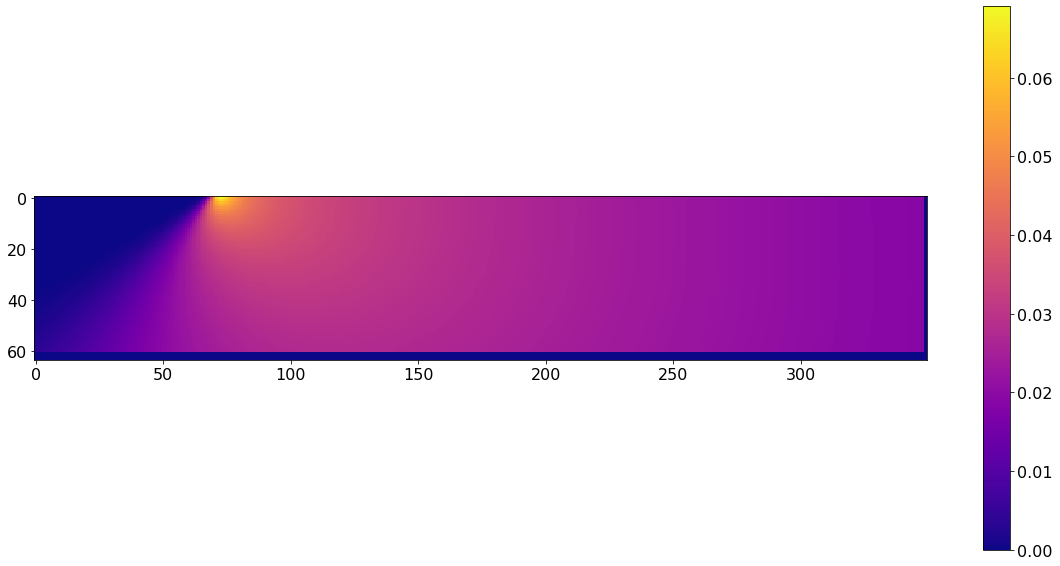

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


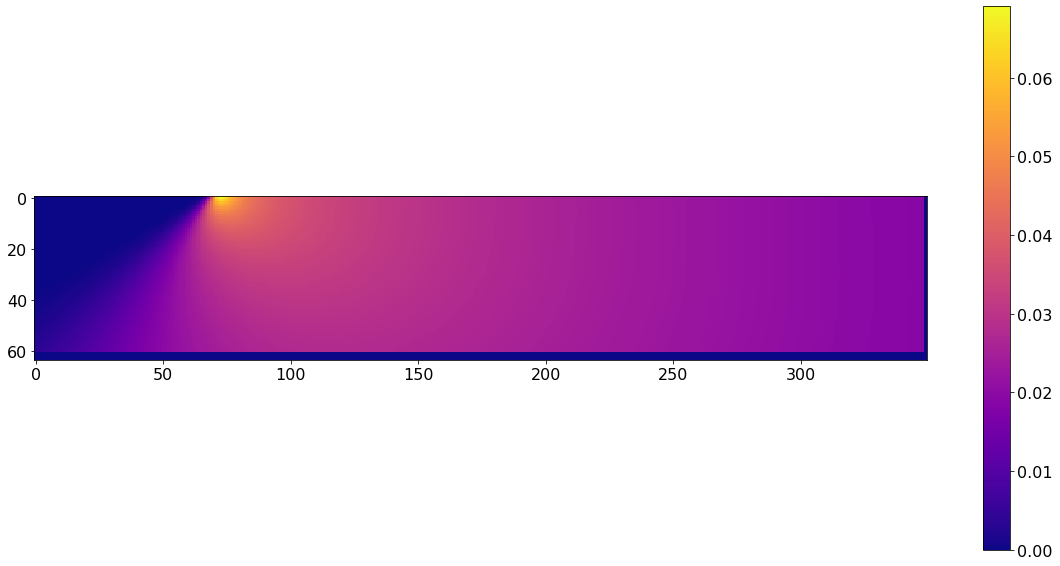

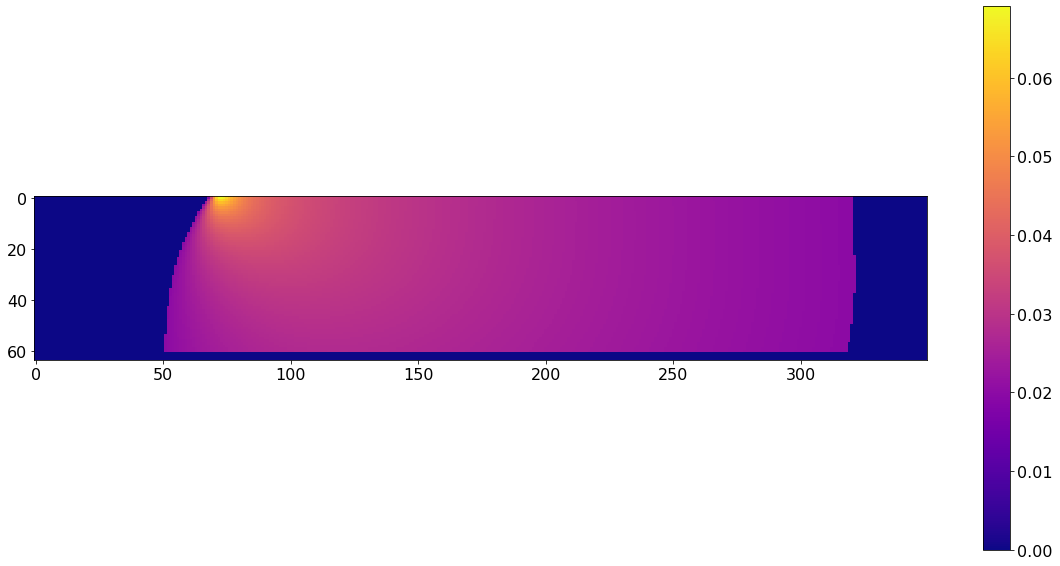

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()